# Fig. 6 derivation notebook: dendritic clustering

이 노트북의 목표는 Fig. 6 결과만 보여주는 것이 아니라,


<p align="center">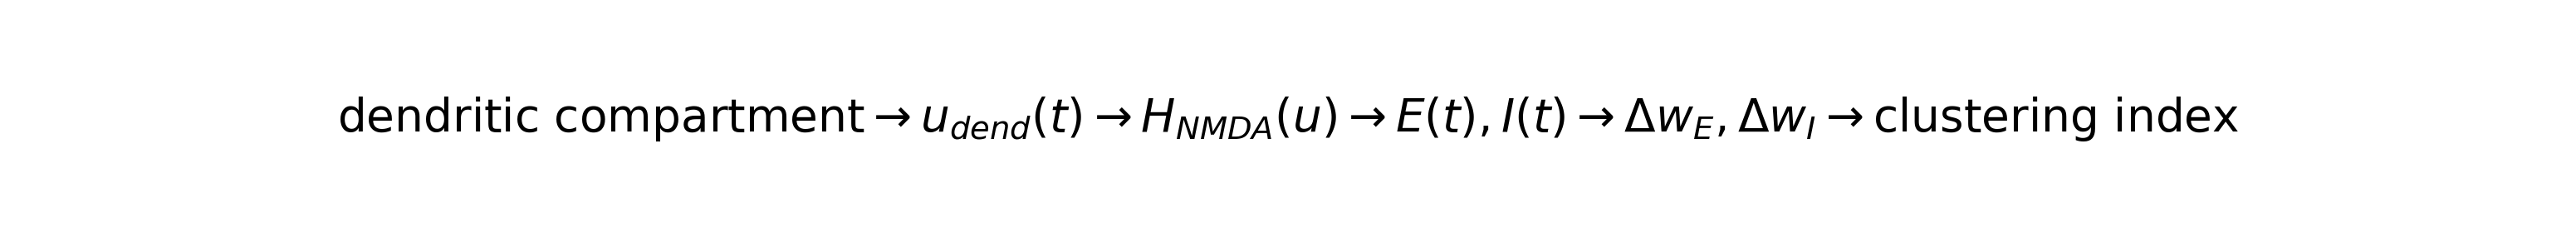</p>


순서로 **수식이 어떻게 결과 플롯으로 이어지는지** 확인하는 것이다.

발표용 핵심 문장:

> Fig. 6에서는 co-active excitatory inputs가 충분히 많고 dendrite가 soma와 적절히 coupling되어 있을 때, dendritic branch 안에서 같은 feature를 가진 synapse가 살아남아 single-feature selectivity가 생긴다. 반대로 co-active group이 작거나 조건이 맞지 않으면 uncorrelated synapses가 상대적으로 남아 mixed selectivity가 된다.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTDIR = Path("fig6_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

def save_and_show(fig, filename, dpi=300):
    """Save a figure to OUTDIR, display it in the notebook, and close it."""
    save_path = OUTDIR / filename

    if SAVE_FIGURES:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"saved: {save_path.resolve()}")

    plt.show()
    plt.close(fig)

rng = np.random.default_rng(1)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

print(f"Figure output directory: {OUTDIR.resolve()}")


Figure output directory: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs


## 1. Fig. 6의 구조: soma + dendritic branch

논문 Fig. 6의 핵심 구조는 다음과 같다.

- soma는 spike를 발생시키는 LIF compartment이다.
- dendrite는 passive compartment이다.
- synaptic input은 dendrite로 들어간다.
- dendrite와 soma는 coupling strength $J(d)$로 연결된다.
- dendrite 1은 plastic synapses를 가진 branch, dendrite 2는 background/noise branch로 볼 수 있다.

업로드한 Brian2 코드도 같은 구조를 쓴다. `DendriteSimulation` 안에서 soma 변수는 `u`, plastic dendrite는 `ud`, background dendrite는 `ub`로 구현되어 있고, 기록 변수도 `u_soma`, `u_dend1`, `u_dend2`, `E_trace`, `I_trace`, `w_corr`, `w_uncorr`, `w_i_mean`으로 저장된다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\01_conceptual_circuit.png


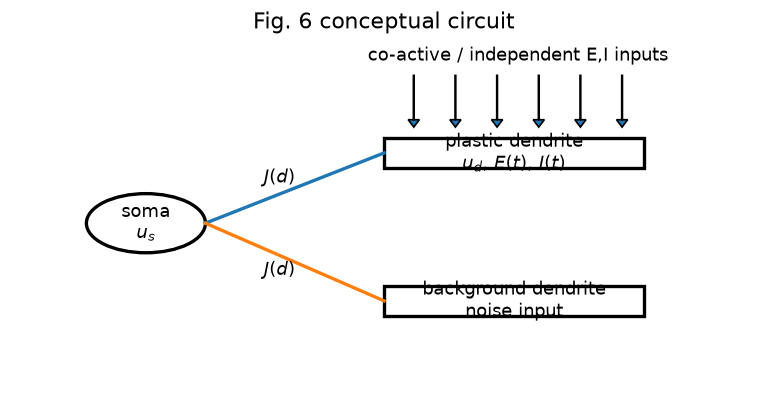

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

# soma and dendrites
soma = plt.Circle((0.18, 0.5), 0.08, fill=False, lw=2)
d1 = plt.Rectangle((0.50, 0.65), 0.35, 0.08, fill=False, lw=2)
d2 = plt.Rectangle((0.50, 0.25), 0.35, 0.08, fill=False, lw=2)
ax.add_patch(soma)
ax.add_patch(d1)
ax.add_patch(d2)

ax.plot([0.26, 0.50], [0.50, 0.69], lw=2)
ax.plot([0.26, 0.50], [0.50, 0.29], lw=2)

ax.text(0.18, 0.5, 'soma\n$u_s$', ha='center', va='center')
ax.text(0.675, 0.69, 'plastic dendrite\n$u_d$, $E(t)$, $I(t)$', ha='center', va='center')
ax.text(0.675, 0.29, 'background dendrite\nnoise input', ha='center', va='center')
ax.text(0.36, 0.61, '$J(d)$', ha='center')
ax.text(0.36, 0.36, '$J(d)$', ha='center')

# inputs
for x in np.linspace(0.54, 0.82, 6):
    ax.arrow(x, 0.90, 0, -0.14, head_width=0.015, head_length=0.02, length_includes_head=True)
ax.text(0.68, 0.94, 'co-active / independent E,I inputs', ha='center')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Fig. 6 conceptual circuit')
save_and_show(fig, "01_conceptual_circuit.png")

## 2. Soma--dendrite coupling 유도

논문 Methods의 two-layer neuron에서 soma dynamics는 다음 형태로 쓸 수 있다.


<p align="center">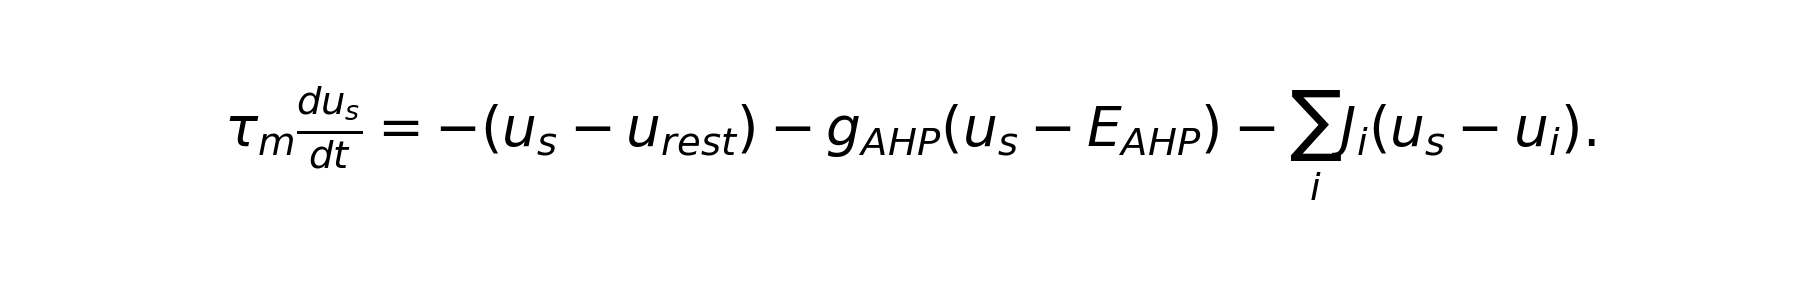</p>


dendrite 쪽은 다음과 같다.


<p align="center">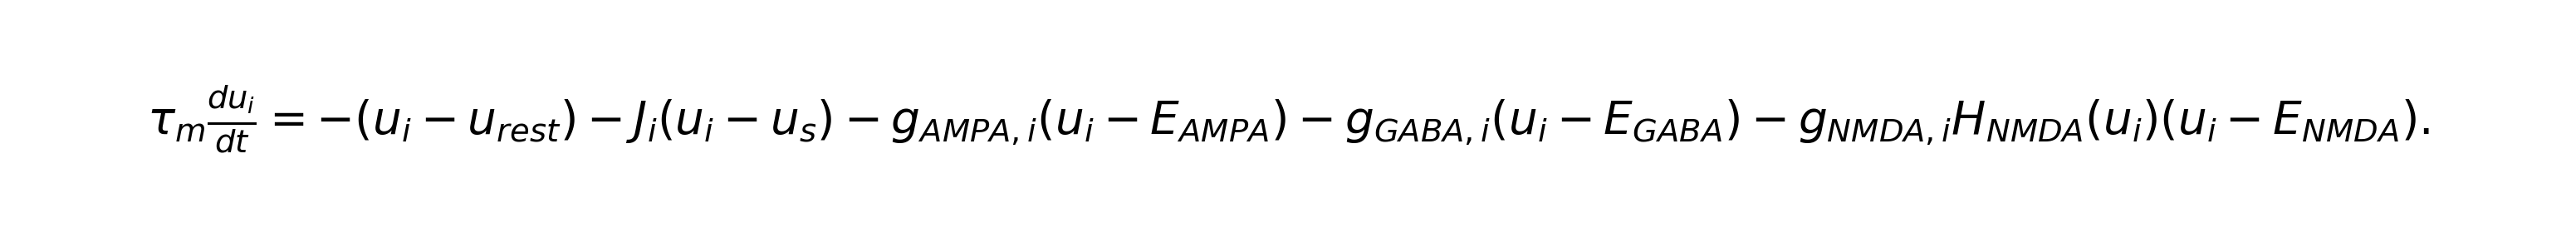</p>


논문에서는 soma와 dendrite 사이 coupling을 distance의 함수로 둔다.


<p align="center">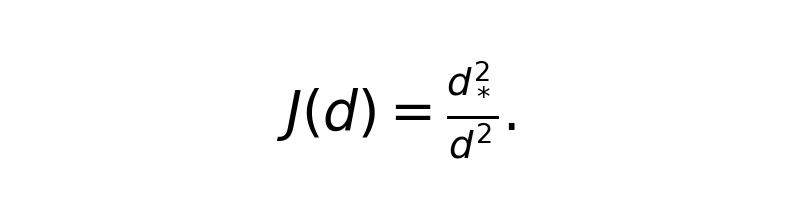</p>


즉, dendrite가 soma에서 멀수록 $J$가 작아지고, soma spike에 미치는 영향도 약해진다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\02_distance_dependent_coupling.png


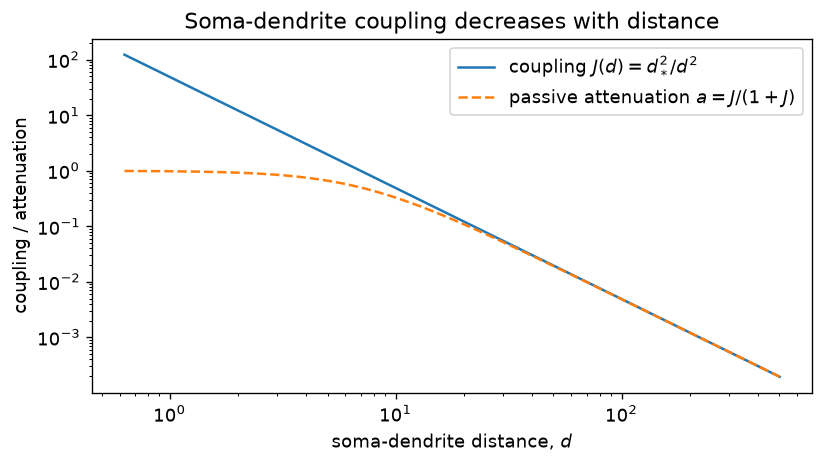

In [14]:
d = np.logspace(-0.2, 2.7, 300)  # arbitrary um-like distance scale
d_star = 7.0
J = (d_star ** 2) / (d ** 2)
attenuation = J / (1.0 + J)  # from J = a/(1-a) -> a = J/(1+J)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(d, J, label='coupling $J(d)=d_*^2/d^2$')
ax.loglog(d, attenuation, linestyle='--', label='passive attenuation $a=J/(1+J)$')
ax.set_xlabel('soma-dendrite distance, $d$')
ax.set_ylabel('coupling / attenuation')
ax.set_title('Soma-dendrite coupling decreases with distance')
ax.legend()
plt.tight_layout()
save_and_show(fig, "02_distance_dependent_coupling.png")

## 3. NMDA voltage gate: dendrite depolarization이 E trace를 키운다

NMDA current는 voltage-dependent magnesium block을 반영한다.


<p align="center">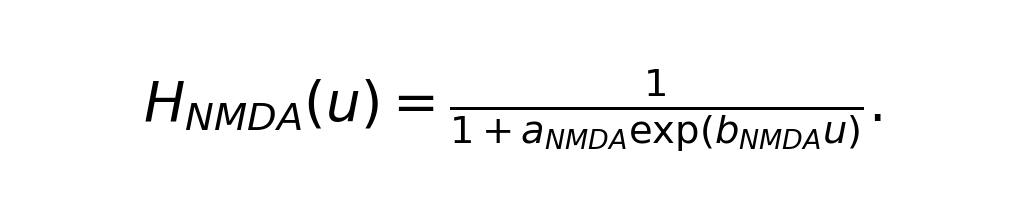</p>


현재 Brian2 코드에서는 `a_nmda = 0.15`, `b_nmda = -0.08`로 구현되어 있다. 
$u$가 덜 음수, 즉 더 depolarized되면 $H_{NMDA}(u)$가 커진다. 
따라서 같은 presynaptic input이라도 dendrite가 depolarized되어 있으면 NMDA contribution이 커지고, 이후 $E(t)$가 커진다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\03_nmda_voltage_gate.png


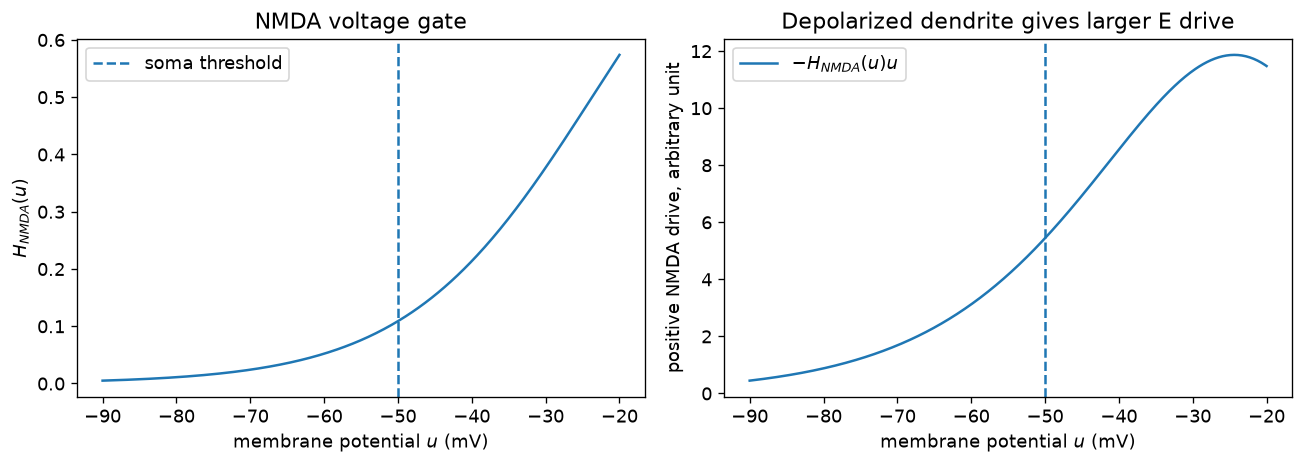

In [15]:
a_nmda = 0.15
b_nmda = -0.08
u = np.linspace(-90, -20, 400)
H = 1.0 / (1.0 + a_nmda * np.exp(b_nmda * u))

# Code-level positive NMDA drive used in the translated code: -g_nmda * H(u) * u
nmda_drive = -H * u

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(u, H)
axes[0].axvline(-50, linestyle='--', label='soma threshold')
axes[0].set_xlabel('membrane potential $u$ (mV)')
axes[0].set_ylabel('$H_{NMDA}(u)$')
axes[0].set_title('NMDA voltage gate')
axes[0].legend()

axes[1].plot(u, nmda_drive, label='$-H_{NMDA}(u)u$')
axes[1].axvline(-50, linestyle='--')
axes[1].set_xlabel('membrane potential $u$ (mV)')
axes[1].set_ylabel('positive NMDA drive, arbitrary unit')
axes[1].set_title('Depolarized dendrite gives larger E drive')
axes[1].legend()
plt.tight_layout()
save_and_show(fig, "03_nmda_voltage_gate.png")

## 4. Code-dependent traces: $E(t)$와 $I(t)$

Fig. 6에서는 dendrite에서 들어온 current history를 두 trace로 요약한다.


<p align="center">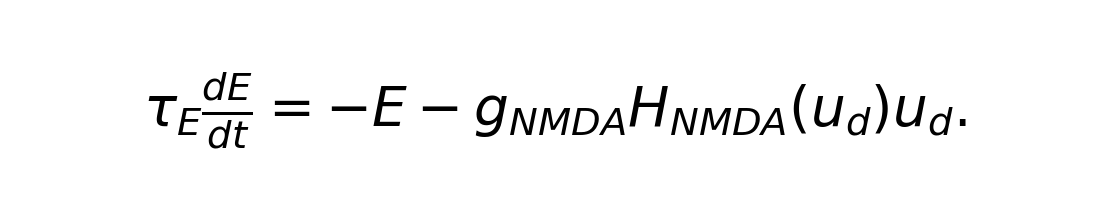</p>



<p align="center">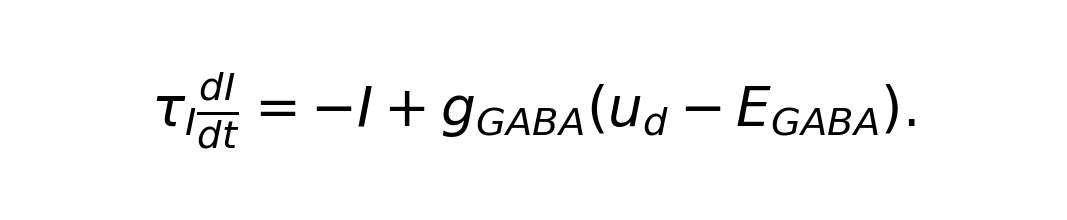</p>


현재 코드의 핵심 대응은 다음과 같다.

```python
E_trace = E_trace * decay_E - gd_nmda * H_d * ud * one_minus_decay_E
I_trace = I_trace * decay_I + gd_gaba * (ud - E_gaba) * one_minus_decay_I
```

아래 셀에서는 conductance pulse가 들어왔을 때 $E(t)$, $I(t)$가 어떻게 누적되고 decay하는지 먼저 단순하게 확인한다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\04_dendritic_trace_example.png


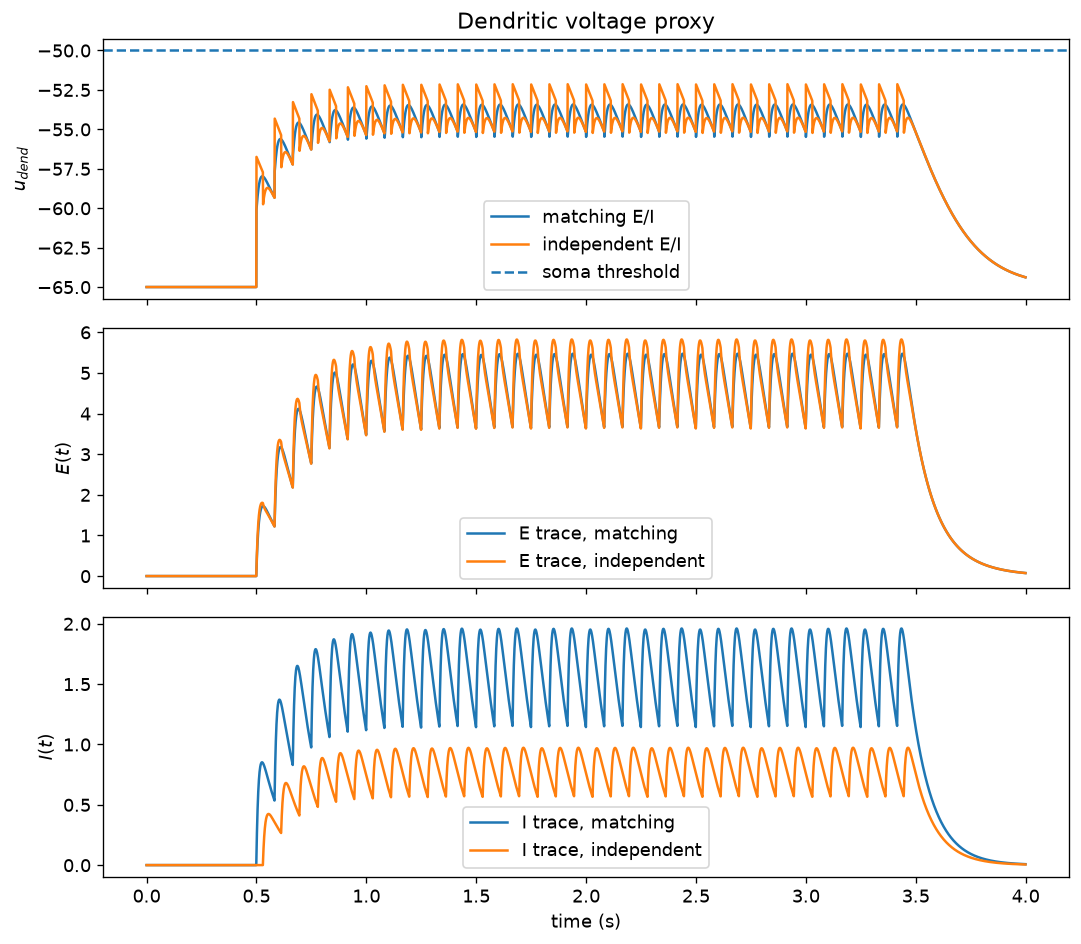

In [16]:
def simulate_traces(T=4.0, dt=0.001, pulse_rate=12, correlated=True, seed=2):
    rng = np.random.default_rng(seed)
    t = np.arange(0, T, dt)
    tau_nmda = 0.150
    tau_gaba = 0.010
    tau_E = 0.010
    tau_I = 0.100
    E_gaba = -80.0
    u_rest = -65.0

    gd_nmda = np.zeros_like(t)
    gd_gaba = np.zeros_like(t)
    E = np.zeros_like(t)
    I = np.zeros_like(t)
    ud = np.zeros_like(t)
    ud[0] = u_rest

    # correlated case: bursts shared by E/I; independent case: mismatch
    event_times = np.arange(0.5, T-0.5, 1.0/pulse_rate)
    for et in event_times:
        idx = int(et/dt)
        if idx < len(t):
            gd_nmda[idx] += 0.6
            if correlated:
                gd_gaba[idx] += 0.5
            else:
                # delayed and weaker/mismatched inhibition
                j = min(len(t)-1, idx + int(0.030/dt))
                gd_gaba[j] += 0.25

    for k in range(1, len(t)):
        gd_nmda[k] += gd_nmda[k-1] * np.exp(-dt/tau_nmda)
        gd_gaba[k] += gd_gaba[k-1] * np.exp(-dt/tau_gaba)

        # simple dendritic voltage proxy: E depolarizes, I hyperpolarizes
        ud[k] = u_rest + 22*gd_nmda[k]/(1+gd_nmda[k]) - 10*gd_gaba[k]/(1+gd_gaba[k])
        H = 1.0/(1.0 + 0.15*np.exp(-0.08*ud[k]))
        E[k] = E[k-1]*np.exp(-dt/tau_E) + (-gd_nmda[k]*H*ud[k])*(1-np.exp(-dt/tau_E))
        I[k] = I[k-1]*np.exp(-dt/tau_I) + (gd_gaba[k]*(ud[k]-E_gaba))*(1-np.exp(-dt/tau_I))

    return pd.DataFrame({'t': t, 'u_dend': ud, 'g_nmda': gd_nmda, 'g_gaba': gd_gaba, 'E_trace': E, 'I_trace': I})

tr_corr = simulate_traces(correlated=True)
tr_ind = simulate_traces(correlated=False)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(tr_corr['t'], tr_corr['u_dend'], label='matching E/I')
axes[0].plot(tr_ind['t'], tr_ind['u_dend'], label='independent E/I')
axes[0].axhline(-50, linestyle='--', label='soma threshold')
axes[0].set_ylabel('$u_{dend}$')
axes[0].set_title('Dendritic voltage proxy')
axes[0].legend()

axes[1].plot(tr_corr['t'], tr_corr['E_trace'], label='E trace, matching')
axes[1].plot(tr_ind['t'], tr_ind['E_trace'], label='E trace, independent')
axes[1].set_ylabel('$E(t)$')
axes[1].legend()

axes[2].plot(tr_corr['t'], tr_corr['I_trace'], label='I trace, matching')
axes[2].plot(tr_ind['t'], tr_ind['I_trace'], label='I trace, independent')
axes[2].set_ylabel('$I(t)$')
axes[2].set_xlabel('time (s)')
axes[2].legend()
plt.tight_layout()
save_and_show(fig, "04_dendritic_trace_example.png")

## 5. Excitatory plasticity: LTP, heterosynaptic weakening, LTD, inhibitory gate

Fig. 6에서 co-active synapse가 clustering될지 여부는 excitatory weight update가 어느 방향으로 가는지에 달려 있다.

단순화해서 post event에서의 excitatory update를 쓰면,


<p align="center">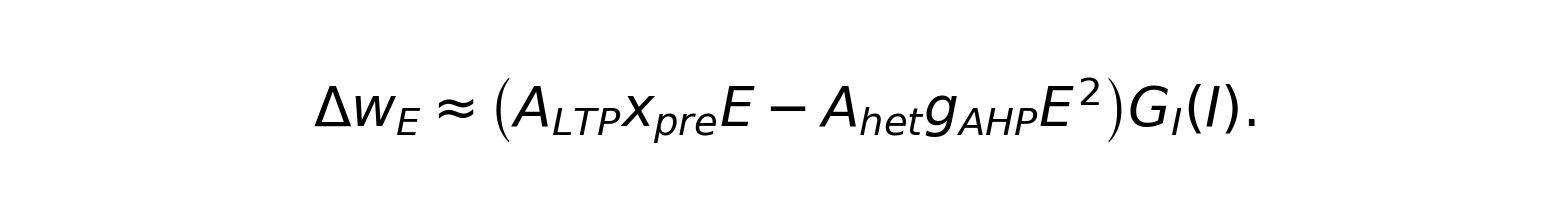</p>


pre event에서 LTD는 다음처럼 들어간다.


<p align="center">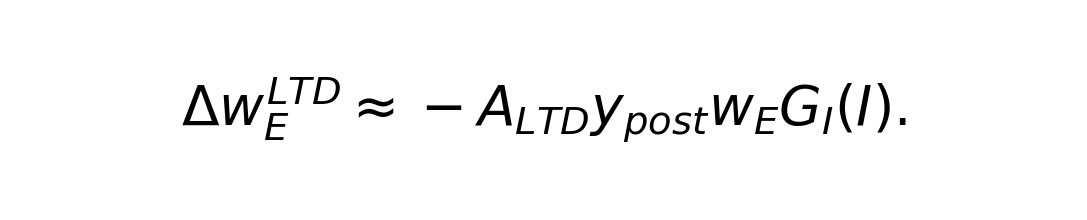</p>


여기서 inhibitory gate는 코드상 다음 형태다.


<p align="center">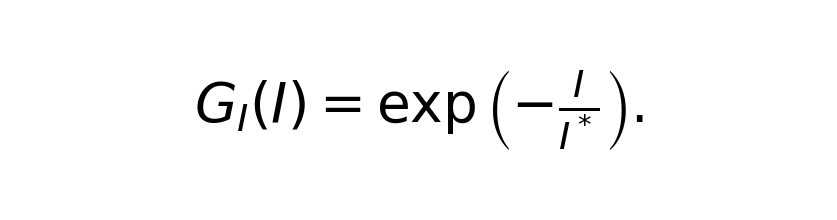</p>


즉, inhibition이 크면 $G_I$가 작아져서 excitatory plasticity가 꺼진다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\05_inhibitory_gate_and_excitatory_plasticity.png


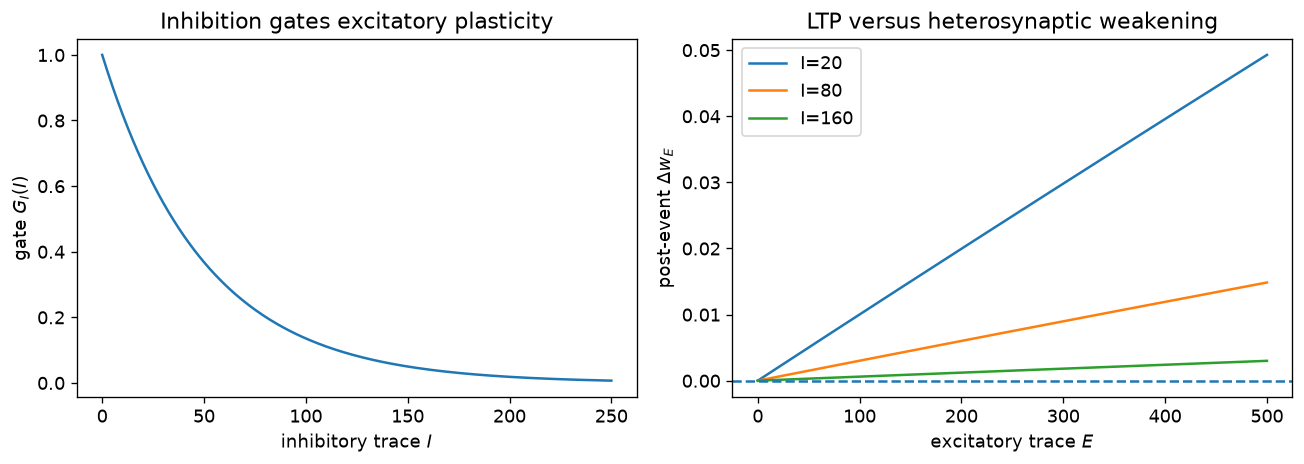

In [17]:
E = np.linspace(0, 500, 400)
I_values = [20, 80, 160]
A_ltp = 0.00003
A_het = 0.0002 * A_ltp
xpre = 5.0
g_ahp = 1.0
Istar = 50.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
I_grid = np.linspace(0, 250, 300)
G = np.exp(-I_grid / Istar)
axes[0].plot(I_grid, G)
axes[0].set_xlabel('inhibitory trace $I$')
axes[0].set_ylabel('gate $G_I(I)$')
axes[0].set_title('Inhibition gates excitatory plasticity')

for I in I_values:
    gate = np.exp(-I/Istar)
    ltp = A_ltp * xpre * E
    het = A_het * g_ahp * E**2
    net = (ltp - het) * gate
    axes[1].plot(E, net, label=f'I={I}')
axes[1].axhline(0, linestyle='--')
axes[1].set_xlabel('excitatory trace $E$')
axes[1].set_ylabel('post-event $\Delta w_E$')
axes[1].set_title('LTP versus heterosynaptic weakening')
axes[1].legend()
plt.tight_layout()
save_and_show(fig, "05_inhibitory_gate_and_excitatory_plasticity.png")

## 6. Inhibitory plasticity: local E/I balance setpoint

Inhibitory plasticity는 spike timing trace와 함께 local current balance를 본다.

논문식의 간단한 형태는 다음과 같다.


<p align="center">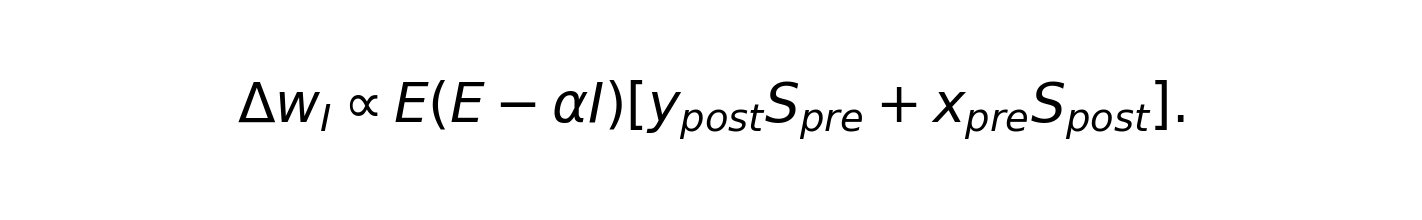</p>


현재 Brian2 코드에서는 같은 구조가 `balance_signal`로 구현되어 있다.


<p align="center">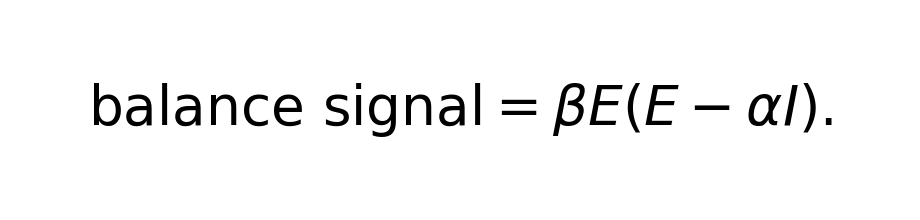</p>


- $E > \alpha I$: inhibition이 부족하므로 inhibitory weight가 증가하는 방향.
- $E < \alpha I$: inhibition이 상대적으로 강하므로 inhibitory weight가 감소하는 방향.
- $E = \alpha I$: balance setpoint.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\06_codependent_balance_signal.png


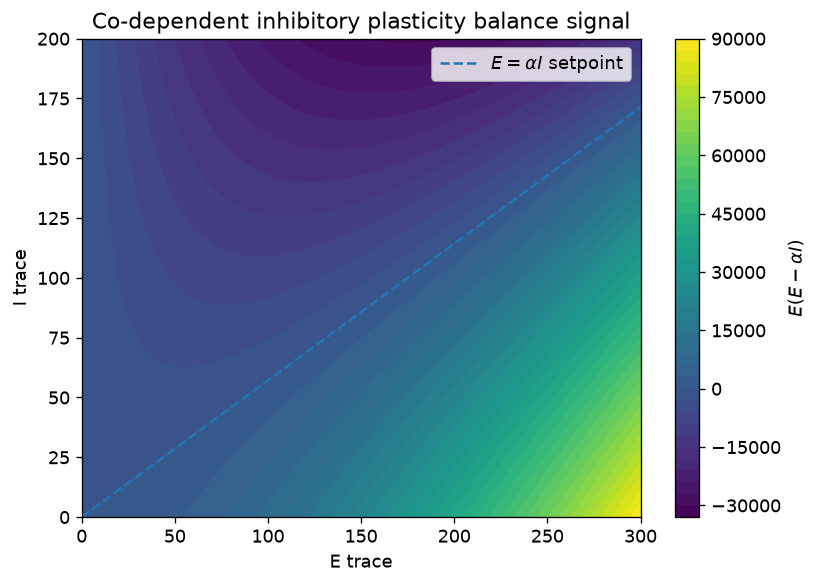

In [18]:
alpha = 1.75
E_grid = np.linspace(0, 300, 160)
I_grid = np.linspace(0, 200, 160)
EE, II = np.meshgrid(E_grid, I_grid)
balance_signal = EE * (EE - alpha * II)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.contourf(EE, II, balance_signal, levels=40)
ax.plot(E_grid, E_grid/alpha, linestyle='--', label='$E=\\alpha I$ setpoint')
ax.set_xlabel('E trace')
ax.set_ylabel('I trace')
ax.set_title('Co-dependent inhibitory plasticity balance signal')
ax.legend()
fig.colorbar(im, ax=ax, label='$E(E-\\alpha I)$')
plt.tight_layout()
save_and_show(fig, "06_codependent_balance_signal.png")

## 7. Clustering index 유도

Fig. 6의 결과 변수는 clustering index이다.


<p align="center">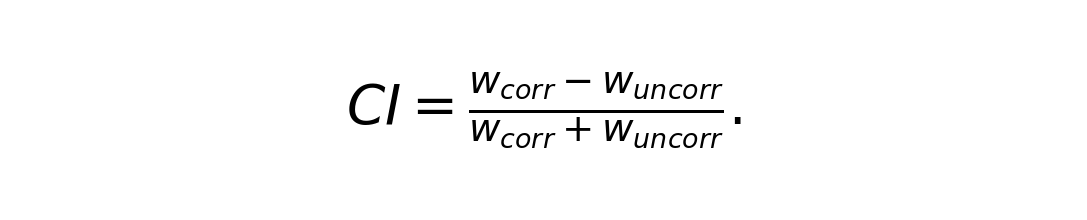</p>


- $CI>0$: correlated/co-active synapses가 더 강하다. 즉, single-feature selectivity 쪽.
- $CI<0$: uncorrelated synapses가 더 강하다. 즉, mixed-feature selectivity 쪽.
- $CI\approx0$: 둘이 비슷하다.

업로드한 Brian2 코드도 이 정의를 그대로 사용한다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\07_clustering_index_definition.png


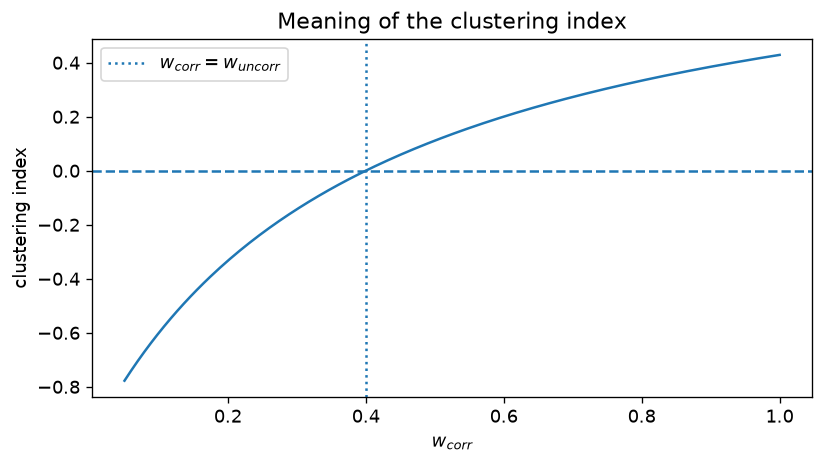

In [19]:
def clustering_index(w_corr, w_uncorr):
    return (w_corr - w_uncorr) / (w_corr + w_uncorr)

w_corr = np.linspace(0.05, 1.0, 200)
w_uncorr_fixed = 0.4
ci = clustering_index(w_corr, w_uncorr_fixed)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_corr, ci)
ax.axhline(0, linestyle='--')
ax.axvline(w_uncorr_fixed, linestyle=':', label='$w_{corr}=w_{uncorr}$')
ax.set_xlabel('$w_{corr}$')
ax.set_ylabel('clustering index')
ax.set_title('Meaning of the clustering index')
ax.legend()
plt.tight_layout()
save_and_show(fig, "07_clustering_index_definition.png")

## 8. Toy derivation: co-active fraction이 커질수록 single-feature selectivity로 이동

아래 toy model은 실제 Brian2 simulation을 대체하려는 것이 아니라, Fig. 6의 수식 구조를 직관적으로 보여주기 위한 것이다.

핵심 가정:

1. co-active excitatory group이 커질수록 dendrite에서 $E(t)$가 더 안정적으로 커진다.
2. inhibition이 matching되면 $I(t)$도 함께 커져서 excitatory plasticity gate가 부분적으로 닫힌다.
3. proximal dendrite는 soma spike와 coupling이 강해서 작은 co-active group도 LTP를 유도하기 쉽다.
4. distal dendrite는 coupling이 약해서 더 큰 co-active group이 필요하다.

saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\08_toy_clustering_curve.png


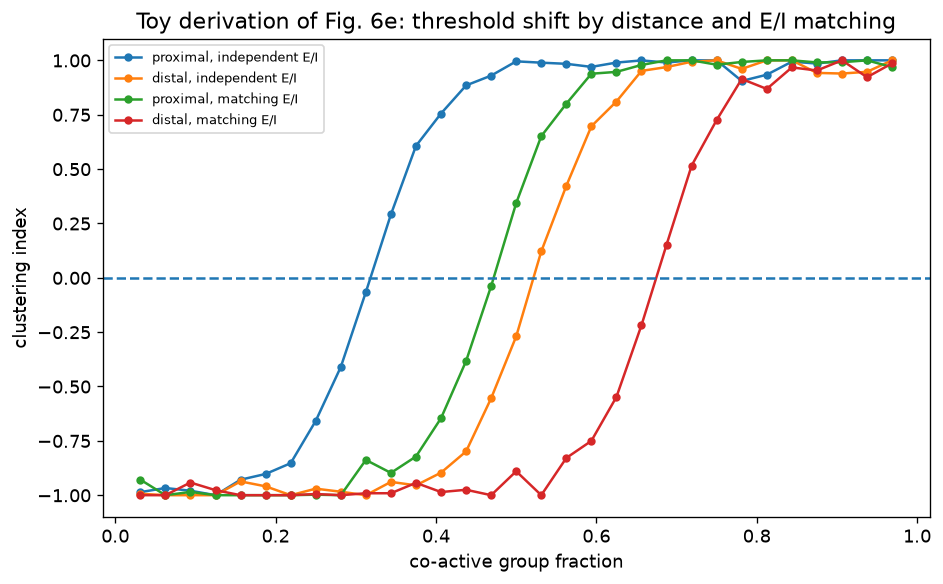

In [20]:
def toy_clustering_curve(group_fracs, distance=5.0, matching=True, seed=1):
    rng = np.random.default_rng(seed)
    d_star = 7.0
    J = (d_star**2) / (distance**2)
    coupling = J / (1 + J)

    # threshold is larger for distal dendrites and matching E/I conditions
    base_threshold = 0.30 + 0.25 * (1 - coupling)
    if matching:
        base_threshold += 0.15

    # smooth transition from mixed to single feature selectivity
    slope = 12.0
    ci = np.tanh(slope * (group_fracs - base_threshold))

    # add small deterministic-looking fluctuations, like compressed simulations
    ci += rng.normal(0, 0.035, size=len(group_fracs))
    return np.clip(ci, -1, 1)

group_fracs = np.arange(1, 32) / 32.0

curves = {
    'proximal, independent E/I': toy_clustering_curve(group_fracs, distance=2.0, matching=False, seed=1),
    'distal, independent E/I': toy_clustering_curve(group_fracs, distance=20.0, matching=False, seed=2),
    'proximal, matching E/I': toy_clustering_curve(group_fracs, distance=2.0, matching=True, seed=3),
    'distal, matching E/I': toy_clustering_curve(group_fracs, distance=20.0, matching=True, seed=4),
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, y in curves.items():
    ax.plot(group_fracs, y, marker='o', ms=4, label=label)
ax.axhline(0, linestyle='--')
ax.set_xlabel('co-active group fraction')
ax.set_ylabel('clustering index')
ax.set_title('Toy derivation of Fig. 6e: threshold shift by distance and E/I matching')
ax.legend(fontsize=8)
plt.tight_layout()
save_and_show(fig, "08_toy_clustering_curve.png")

## 9. Toy heatmap: Fig. 6f 형태

Fig. 6f는 co-active group size와 soma-dendrite distance의 2D map으로 clustering index를 보여준다.

아래 플롯은 그 논리를 보여주는 설명용 heatmap이다.

C:\Users\pc\AppData\Local\Temp\ipykernel_21792\2611476909.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: C:\Users\pc\Desktop\KIST\3rd\code\jupyter\fig6_outputs\09_clustering_surface.png


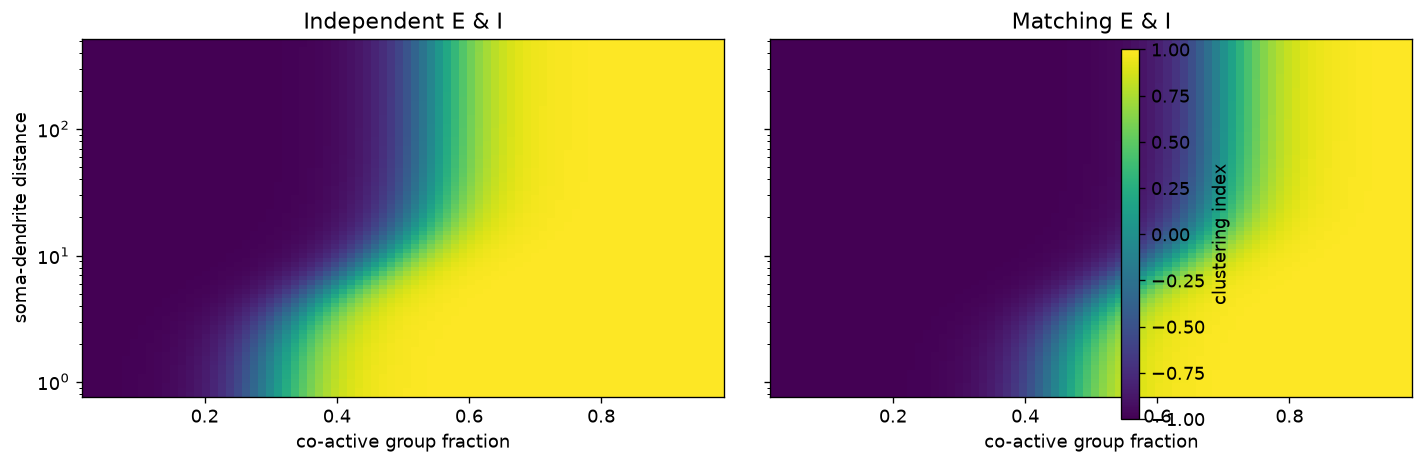

In [21]:
distances = np.logspace(-0.1, 2.7, 80)
fractions = np.linspace(0.02, 0.98, 80)
FF, DD = np.meshgrid(fractions, distances)

def toy_ci_surface(FF, DD, matching):
    d_star = 7.0
    J = (d_star**2) / (DD**2)
    coupling = J / (1 + J)
    threshold = 0.30 + 0.25 * (1 - coupling)
    if matching:
        threshold += 0.15
    return np.tanh(12.0 * (FF - threshold))

surface_ind = toy_ci_surface(FF, DD, matching=False)
surface_match = toy_ci_surface(FF, DD, matching=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, surface, title in zip(axes, [surface_ind, surface_match], ['Independent E & I', 'Matching E & I']):
    im = ax.pcolormesh(fractions, distances, surface, shading='auto', vmin=-1, vmax=1)
    ax.set_yscale('log')
    ax.set_xlabel('co-active group fraction')
    ax.set_title(title)
axes[0].set_ylabel('soma-dendrite distance')
fig.colorbar(im, ax=axes, label='clustering index')
plt.tight_layout()
save_and_show(fig, "09_clustering_surface.png")

## 10. 실제 Brian2 코드 연결

아래 셀은 업로드한 `dendrites_brian2.py`를 그대로 불러와서 실행하는 선택 셀이다.

기본값은 `RUN_BRIAN2 = False`로 두었다. 이유는 노트북을 여는 환경에 Brian2가 없으면 에러가 나기 때문이다. 
네 PC처럼 Brian2가 설치된 환경에서는 `RUN_BRIAN2 = True`로 바꾸고 실행하면 된다.

추천 순서:

1. 먼저 `mode="smoke"`로 실행해서 전체 흐름 확인.
2. 그 다음 `mode="quick"`.
3. 최종 제출/발표용은 시간이 허락하면 `mode="medium"`.

In [22]:
RUN_BRIAN2 = False
MODE = 'smoke'   # 'smoke', 'quick', 'medium', or 'long'
SEED = 1

if RUN_BRIAN2:
    import importlib.util
    import sys
    from pathlib import Path

    script_path = Path('dendrites_brian2.py')
    spec = importlib.util.spec_from_file_location('dendrites_brian2', script_path)
    dend = importlib.util.module_from_spec(spec)
    sys.modules['dendrites_brian2'] = dend
    spec.loader.exec_module(dend)

    cfg = dend.get_mode_config(MODE)
    rows = []
    example_trace = None

    for i, ne_corr in enumerate(cfg['group_sizes']):
        record = ne_corr == 16
        row, trace = dend.run_one_group(
            ne_corr=ne_corr,
            warmup_s=cfg['warmup_s'],
            plastic_min=cfg['plastic_min'],
            dt_ms=cfg['dt_ms'],
            seed=SEED+i,
            record=record,
        )
        rows.append(row)
        if record:
            example_trace = trace

    brian_df = pd.DataFrame(rows)
    display(brian_df.head())

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(brian_df['coactive_fraction'], brian_df['clustering_index'], marker='o')
    ax.axhline(0, linestyle='--')
    ax.set_xlabel('co-active group fraction')
    ax.set_ylabel('clustering index')
    ax.set_title(f'Brian2 dendritic clustering ({MODE})')
    plt.tight_layout()
    save_and_show(fig, f"10_brian2_clustering_{MODE}.png")

    if example_trace is not None:
        fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
        axes[0].plot(example_trace['time_s'], example_trace['u_soma'], label='soma')
        axes[0].plot(example_trace['time_s'], example_trace['u_dend1'], label='dendrite 1')
        axes[0].plot(example_trace['time_s'], example_trace['u_dend2'], label='dendrite 2')
        axes[0].set_ylabel('membrane potential')
        axes[0].legend()

        axes[1].plot(example_trace['time_s'], example_trace['E_trace'], label='E trace')
        axes[1].plot(example_trace['time_s'], example_trace['I_trace'], label='I trace')
        axes[1].set_ylabel('trace')
        axes[1].legend()

        axes[2].plot(example_trace['time_s'], example_trace['w_corr'], label='correlated E')
        axes[2].plot(example_trace['time_s'], example_trace['w_uncorr'], label='uncorrelated E')
        axes[2].plot(example_trace['time_s'], example_trace['w_i_mean'], label='mean I')
        axes[2].set_ylabel('weight')
        axes[2].set_xlabel('time (s)')
        axes[2].legend()
        plt.tight_layout()
        save_and_show(fig, f"11_brian2_example_trace_{MODE}.png")
else:
    print('RUN_BRIAN2=False: derivation/toy plots only. Set RUN_BRIAN2=True in a Brian2 environment to run the uploaded simulation code.')

RUN_BRIAN2=False: derivation/toy plots only. Set RUN_BRIAN2=True in a Brian2 environment to run the uploaded simulation code.


## 11. 정리 문장

1. **Dendrite가 계산 단위가 된다.** Synaptic input은 soma에 바로 들어가는 것이 아니라 dendritic compartment에서 먼저 통합된다.
2. **Dendrite voltage가 NMDA current를 조절한다.** $u_d$가 depolarized될수록 $H_{NMDA}(u_d)$가 커지고 $E(t)$가 커진다.
3. **$E(t)$와 $I(t)$가 plasticity의 local state variable이다.** $E$는 LTP와 heterosynaptic weakening을, $I$는 excitatory plasticity gate와 inhibitory balance를 조절한다.
4. **co-active group fraction이 충분히 크면 co-active synapses가 살아남는다.** 그래서 clustering index가 양수가 되고 single-feature selectivity가 된다.
5. **co-active group이 작거나 distal dendrite라 soma spike coupling이 약하면 mixed selectivity가 된다.** 그래서 clustering index가 음수 또는 0 근처에 머문다.

“Fig. 6 결과가 갑자기 나온 게 아니라, dendritic voltage → NMDA/GABA trace → co-dependent plasticity → clustering index로 이어진다”